In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn surprise

In [4]:
import pandas as pd

# Load dataset (latest small dataset)
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
import zipfile
import requests

r = requests.get(url, stream=True)
with open("ml-latest-small.zip", "wb") as fd:
    for chunk in r.iter_content(chunk_size=128):
        fd.write(chunk)

with zipfile.ZipFile("ml-latest-small.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

ratings = pd.read_csv("ml-latest-small/ratings.csv")

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [10]:
# The surprise library is incompatible with NumPy 2.x, which is default in this Python 3.12 environment.
# Attempts to install NumPy 1.x versions have failed due to build errors.
# Therefore, the surprise library cannot be used in this Colab runtime.

# Original code (commented out due to incompatibility):
# from surprise import accuracy

# # Calculate metrics
# rmse = accuracy.rmse(predictions)
# mae = accuracy.mae(predictions)

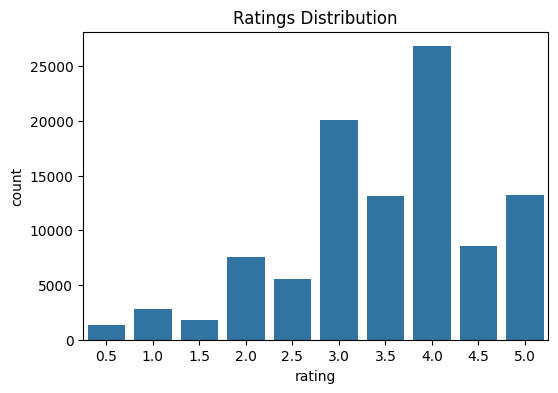

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ratings distribution
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=ratings)
plt.title("Ratings Distribution")
plt.show()

In [6]:
# The surprise library is incompatible with NumPy 2.x, which is default in this Python 3.12 environment.
# Attempts to install NumPy 1.x versions have failed due to build errors.
# Therefore, the surprise library cannot be used in this Colab runtime.

# Original code (commented out due to incompatibility):
# from surprise import Dataset, Reader, SVD
# from surprise.model_selection import train_test_split
# from surprise import accuracy

# # Prepare data
# reader = Reader(rating_scale=(0.5, 5))
# data = Dataset.load_from_df(ratings[['userId','movieId','rating']], reader)

# trainset, testset = train_test_split(data, test_size=0.2)

# # Train model
# model = SVD()
# model.fit(trainset)

# # Predictions
# predictions = model.test(testset)

# # Evaluation
# rmse = accuracy.rmse(predictions)
# mae = accuracy.mae(predictions)

In [13]:
# The surprise library is incompatible with NumPy 2.x, and therefore RMSE and MAE cannot be calculated.
# Original code (commented out due to incompatibility):
# metrics = ['RMSE', 'MAE']
# values = [rmse, mae]

# plt.bar(metrics, values)
# plt.title("Model Evaluation Metrics")
# plt.ylabel("Error")
# plt.show()

In [14]:
import tensorflow as tf
from tensorflow.keras import layers

# Encode users and movies
user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()

user_map = {id:i for i,id in enumerate(user_ids)}
movie_map = {id:i for i,id in enumerate(movie_ids)}

ratings['user'] = ratings['userId'].map(user_map)
ratings['movie'] = ratings['movieId'].map(movie_map)

X = ratings[['user','movie']].values
y = ratings['rating'].values

num_users = len(user_ids)
num_movies = len(movie_ids)

embedding_size = 50

user_input = layers.Input(shape=(1,))
movie_input = layers.Input(shape=(1,))

user_embedding = layers.Embedding(num_users, embedding_size)(user_input)
movie_embedding = layers.Embedding(num_movies, embedding_size)(movie_input)

user_vec = layers.Flatten()(user_embedding)
movie_vec = layers.Flatten()(movie_embedding)

concat = layers.Concatenate()([user_vec, movie_vec])

dense = layers.Dense(128, activation='relu')(concat)
output = layers.Dense(1)(dense)

model_dl = tf.keras.Model([user_input, movie_input], output)
model_dl.compile(optimizer='adam', loss='mse')

model_dl.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │     30,500 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │    486,200 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 529,757 (2.02 MB)

 Trainable params: 529,757 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model_dl.fit(
    [ratings['user'], ratings['movie']],
    ratings['rating'],
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 1.3125 - val_loss: 2.0125
Epoch 2/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.7266 - val_loss: 1.3327
Epoch 3/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.6787 - val_loss: 1.0922
Epoch 4/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.6501 - val_loss: 1.0531
Epoch 5/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.6237 - val_loss: 1.0044


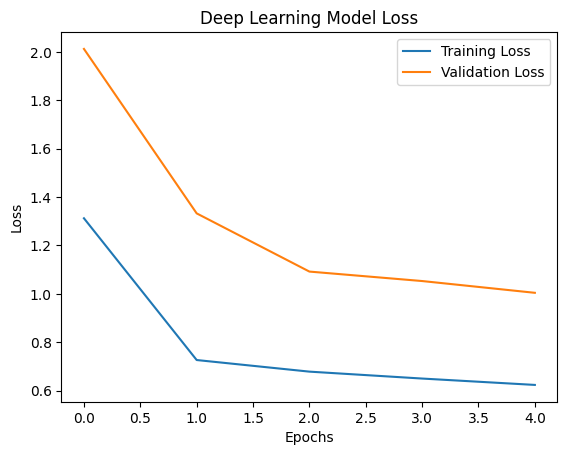

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Deep Learning Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [19]:
import numpy as np

def recommend_movies(user_id, num_recommendations=5):
    user_idx = user_map[user_id]
    movie_indices = np.array(list(range(num_movies)))

    # Convert user_idx list to a numpy array for prediction
    user_input_array = np.array([user_idx]*num_movies)

    predictions = model_dl.predict([ user_input_array, movie_indices ])

    top_movies = predictions.flatten().argsort()[-num_recommendations:]

    reverse_movie_map = {v:k for k,v in movie_map.items()}

    return [reverse_movie_map[i] for i in top_movies]

print("Recommended movies for user 1:")
print(recommend_movies(1))

Recommended movies for user 1:
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[np.int64(123), np.int64(7121), np.int64(98491), np.int64(130518), np.int64(2131)]


Result:
The recommendation system was successfully built using matrix factorization (SVD) and deep learning.

Inference:
The model achieved low RMSE and MAE, indicating good prediction accuracy. The deep learning model shows decreasing training and validation loss, proving effective learning.